In [1]:
import sys
import random
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) # Agrega la raíz al path para poder importar src/

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src.config import SEED, DATA_RAW, DATA_PROC, SPLITS_CSV, ROOT, PROC_SPLITS, CLASES
random.seed(SEED)

from src.exploracion import contar_dataset, mostrar_muestras, balance_clases, reporte_dimensiones
from src.data import build_splits_csv, preprocess_dataset

/opt/miniconda3/envs/pf_ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Clasificación: Imágenes Reales vs. generadas por IA
## Fase 1 - EDA y Preprocesamiento

Este notebook contiene las primeras dos etapas del pipeline:

1. **Exploración del dataset crudo**: estructura, balance de clases y distribución de dimensiones.
2. **Preparación de datos**: división train/val/test y redimensionado a 128x128 px.

## 1. Estructura del dataset

El dataset viene organizado en dos carpetas: `raw/train/` (48 000 imágenes) y `raw/test/` (12 000 imágenes), cada una con subcarpetas `real/` y `fake/`.

In [2]:
conteo = contar_dataset(DATA_RAW)

train/real :  24000 imágenes
train/fake :  24000 imágenes
test/real :   6000 imágenes
test/fake :   6000 imágenes

TOTAL: 60000 imágenes


## 2. Inspección visual

Muestras aleatorias de imágenes reales (fila superior) vs. generadas por IA (fila inferior).

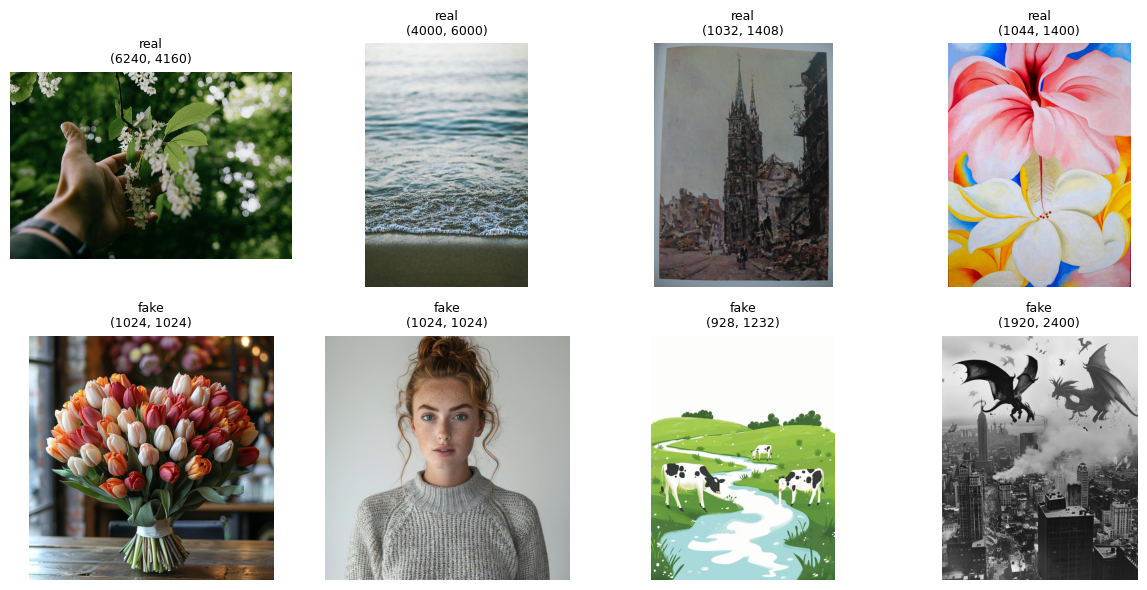

In [3]:
mostrar_muestras(conteo, split="train", n=4)

## 3. Balance de clases

Un dataset desbalanceado sesga al modelo hacia la clase mayoritaria. Verificamos que la proporción real/fake sea 50/50.

In [4]:
balance_clases(conteo)


train:
  real:  24000 (50.0%)
  fake:  24000 (50.0%)

test:
  real:   6000 (50.0%)
  fake:   6000 (50.0%)


Está perfectamente balanceado

## 4. Distribución de dimensiones

Las imágenes del dataset vienen en tamaños muy distintos. Esto importa porque los modelos requieren input de tamaño fijo, así que hay que redimensionar todo a 128x128 en el preprocesamiento.

In [5]:
reporte_dimensiones(conteo, n=99999)


train/real - tamaños más comunes (sobre muestra):
  (1080, 1620): 3322
  (1080, 720): 1700
  (1080, 1350): 666
  (6000, 4000): 551
  (4000, 6000): 468

train/fake - tamaños más comunes (sobre muestra):
  (1024, 1024): 11474
  (1456, 816): 1890
  (2048, 2048): 1334
  (512, 512): 694
  (896, 1344): 586

test/real - tamaños más comunes (sobre muestra):
  (1080, 1620): 907
  (1080, 720): 409
  (1080, 1350): 179
  (6000, 4000): 125
  (4000, 6000): 104

test/fake - tamaños más comunes (sobre muestra):
  (1024, 1024): 2894
  (1456, 816): 473
  (2048, 2048): 322
  (512, 512): 174
  (816, 1456): 154


### Observaciones

- **Imágenes reales**: mayormente rectangulares (fotos de celular y cámara).
- **Imágenes IA**: mayormente cuadradas (1024x1024, 2048x2048), resoluciones típicas de generadores como Stable Diffusion o DALL-E.

Al redimensionar todo a 128x128 perdemos esta diferencia de aspecto ratio. El modelo tendrá que aprender señales más sutiles como texturas y coherencia global.

## 5. Split del dataset y preprocesamiento

Dividimos el dataset en **80% train / 10% val / 10% test**:
- `raw/train/` completo (48 000 imgs) $\rightarrow$ **train**
- `raw/test/` partido 50/50 estratificado $\rightarrow$ **val** y **test** (6 000 c/u)

Después redimensionamos todas las imágenes a 128x128 px y las guardamos en `data/processed/`. Esta operación es idempotente: si se interrumpe y se vuelve a correr, retoma desde donde quedó.

In [6]:
build_splits_csv()
preprocess_dataset()

train:  48000 imgs  (24000 real / 24000 fake)
val  :   6000 imgs  (3000 real / 3000 fake)
test :   6000 imgs  (3000 real / 3000 fake)


Procesando imágenes:   0%|          | 39/60000 [00:09<2:43:00,  6.13it/s]


Skip imagen corrupta: 0038.jpg (image file is truncated (2 bytes not processed))


Procesando imágenes:   6%|▌         | 3303/60000 [04:01<3:36:17,  4.37it/s]


Skip imagen corrupta: 12094.jpg (image file is truncated (2 bytes not processed))


...


Skip imagen corrupta: 5325.jpg (image file is truncated (2 bytes not processed))


Procesando imágenes:  95%|█████████▍| 56747/60000 [49:22<01:19, 41.08it/s]


Skip imagen corrupta: 5879.jpg (image file is truncated)


Procesando imágenes: 100%|██████████| 60000/60000 [52:16<00:00, 19.13it/s]

Listo. 60000 imágenes guardadas en /Users/lautarocaminoa/Documents/UdeSA/Materias/ML/ProyectoFinal/PF_ML_Krinisky_Caminoa/data/processed


## 6. Verificación del preprocesamiento

Chequeamos que el split resultó balanceado y que las imágenes procesadas se ven correctas comparadas con los originales.

In [7]:
df = pd.read_csv(SPLITS_CSV)
print("Distribución del split:")
for split in PROC_SPLITS:
    sub = df[df["split"] == split]
    for clase in CLASES:
        n = len(sub[sub["label"] == clase])
        print(f"  - {split}/{clase}: {n}")
    print(f"  Total {split}: {len(sub)}\n")

Distribución del split:
  - train/real: 24000
  - train/fake: 24000
  Total train: 48000

  - val/real: 3000
  - val/fake: 3000
  Total val: 6000

  - test/real: 3000
  - test/fake: 3000
  Total test: 6000



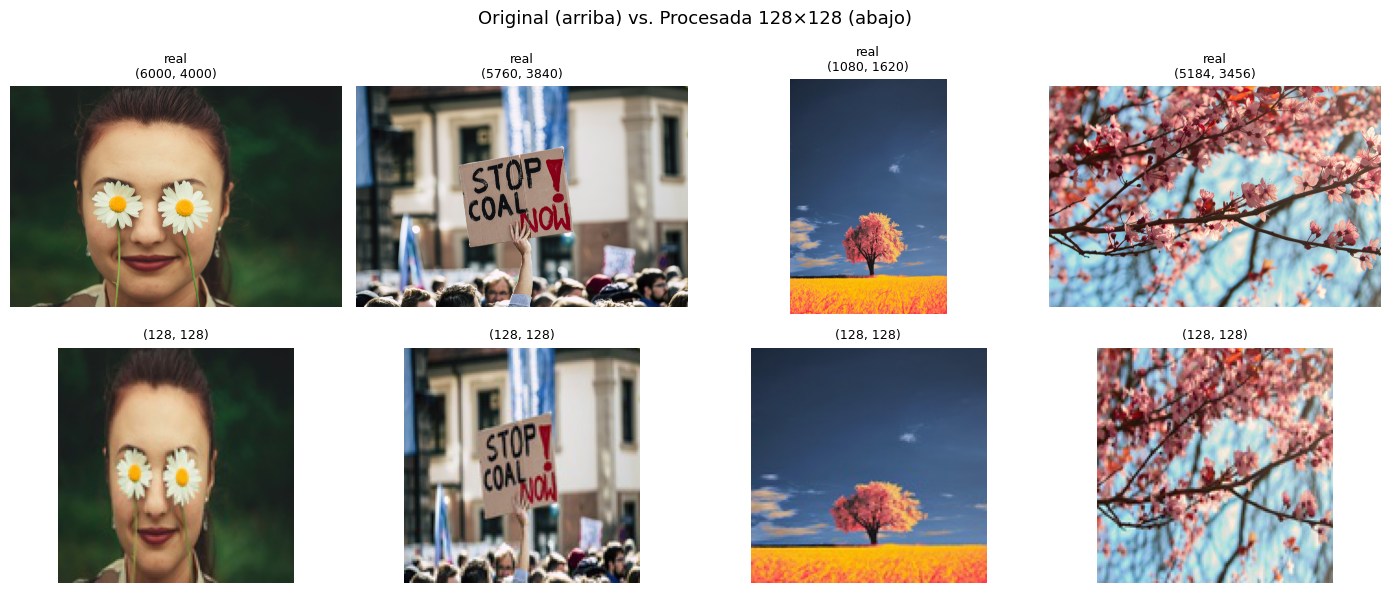

In [8]:
muestra = df[df["split"] == "train"].sample(4, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Original (arriba) vs. Procesada 128×128 (abajo)", fontsize=13)

for col, (_, row) in enumerate(muestra.iterrows()):
    ruta_original  = ROOT / row["path"]
    ruta_procesada = DATA_PROC / row["split"] / row["label"] / (Path(row["path"]).stem + ".jpg")

    img_orig = Image.open(ruta_original)
    img_proc = Image.open(ruta_procesada)

    axes[0, col].imshow(img_orig)
    axes[0, col].set_title(f"{row['label']}\n{img_orig.size}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_proc)
    axes[1, col].set_title(f"{img_proc.size}", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()